# The Rationalist
##### Felix McIntosh

The goal of the rationalist is to see the maximal returns per unit of risk.
The following equation for Sharpe Ratio will be used:

Sharpe Ratio = Rp - Rf / Std(p)

Rp is the average daily returns of the stock 
Rf is the average daily returns of a risk free stock  (US Treasury Bonds were chosen as the risk free stock)
Std(p) is the standard deviation of the stocks daily returns (volatility).

### Key Functions defined in this notebook:
- Invest (inputs: list of companies to invest in, start date, end date, amount), it will use data from prior to the start date and invest in the list of companies given until to end amount and return to cumulative return
- Rf_invest: similar to invest but invests in US Treasury bonds rather than the list of companies given.
- snp_invest: invests in the S&P500 as a whole and returns cumulative returns
- Rational invest: finds the top 10 companies by sharpe ratio and uses the invest function to find cumulative return
- Rolling_sharpe_invest: calculates the top 10 companies by sharpe ratio periodically and reinvests accordingly

More specific documentation is provided where the function is defined.





### Outline of this notebook:
- Cleaning the data 
- Defining functions to find the cumulative return of investing in specific stocks, US Treasury bonds or the S&P 500 as a whole
- Creating functions for static investing whilst maximising the sharpe ratio
- Graphing static investing strategies
- Creating a function for dynamic investing whilst maximising the sharpe ratio
- Finding the optimal amount of stocks to invest in for investing whilst maxmimising sharpe ratio (this was found to be 10)
- Graphing the cumulative returns of different investing strategies over time



Importing the data and necessary libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data_dict = pd.read_csv("data_dictionary.csv")
adj_price = pd.read_csv("adjprice.csv")
sectors = pd.read_csv("SP500.csv")
sector_df = sectors.rename(columns={"Symbol": "ticker"})

adj_price["Date"] = pd.to_datetime(adj_price["Date"], format="%Y%m%d")
adj_price = adj_price.set_index("Date")


Now I am going to rename the columns to their tickers and create a dataframe for matching tickers and names


In [5]:
adj_price=adj_price.rename(columns=lambda x: x.replace(" US Equity", ""))
names = pd.DataFrame(index = adj_price.columns)
names.index.name = "ticker"
names = names.iloc[0:]
names = names.merge(sector_df, on = "ticker",  how = "left")
names.index = names["ticker"]
names = names.drop(columns = ["ticker"])

In [6]:
df = adj_price
df.head()

ticker,0111145D,0202445Q,0203524D,0226226D,0376152D,0440296D,0544749D,0574018D,0598884D,0772031D,...,YNR,YRCW,YUM,YUMC,ZBH,ZETHQ,ZION,ZRN,ZTS,ZTS-W
Date,,,,,,,,,,,,,,,,,,,,,
1993-09-07,13.2719,13.6829,8.4429,8.1042,11.000,57.3245,17.8887,6.8315,28.1246,NaN,...,NaN,144439.5121,NaN,NaN,NaN,6.875,7.1675,30.7970,NaN,NaN
1993-09-08,13.3263,13.5315,8.2147,7.9590,11.000,57.2096,17.8064,6.8315,27.5051,NaN,...,NaN,143691.1208,NaN,NaN,NaN,6.750,6.9766,30.0188,NaN,NaN
1993-09-09,13.7070,13.3800,8.7852,8.0627,11.125,59.1625,17.6831,6.8315,27.7529,NaN,...,NaN,143691.1208,NaN,NaN,NaN,6.625,6.9554,30.0188,NaN,NaN
1993-09-10,13.3807,13.4810,9.4127,8.0368,11.125,59.6220,17.6420,6.8773,27.5051,NaN,...,NaN,145187.9033,NaN,NaN,NaN,6.750,7.2099,29.6852,NaN,NaN
1993-09-11,13.3807,13.4810,9.4127,8.0368,11.125,59.6220,17.6420,6.8773,27.5051,NaN,...,NaN,145187.9033,NaN,NaN,NaN,6.750,7.2099,29.6852,NaN,NaN


First we will be only taking into consideration the stocks that were in the S&P 500 throughout at least 90% of the date range



In [8]:
coverage = df.notna().mean()
df = df.loc[:,coverage >= 0.9]

In [9]:
df = df.dropna()
df = df[~df.iloc[:, 1:].duplicated()]
df = df.drop(df.columns[1], axis=1)

In [10]:
df.head()

ticker,1436513D,AAPL,ABC,ABMD,ABT,ABX,ADBE,ADI,ADM,ADP,...,WY,X,XEL,XL,XLNX,XOM,XRAY,XRX,YRCW,ZION
Date,,,,,,,,,,,,,,,,,,,,,
1996-02-28,3.9666,0.8753,2.9793,6.063,5.4616,23.8016,4.1685,7.2854,9.5428,10.3097,...,8.0538,23.0299,8.5667,19.6972,8.2626,10.7800,5.8269,40.5005,72042.1892,13.4914
1996-02-29,4.0085,0.8674,2.9793,6.063,5.5111,23.6065,4.1377,7.0556,9.3605,9.9564,...,7.8455,22.5986,8.4594,19.2825,7.0334,10.9522,5.7542,39.3304,71637.4578,13.4232
1996-03-01,3.9037,0.8477,2.8766,6.438,5.5771,23.5089,4.0296,6.5634,9.4212,10.0848,...,7.7761,22.6849,8.6096,19.3517,5.6905,10.9867,5.6453,39.1417,72042.1892,13.5142
1996-03-04,4.0434,0.8280,2.9279,6.063,5.7916,22.5335,3.9987,6.4321,9.4212,9.9564,...,8.1464,23.1162,8.6955,19.5936,5.2352,10.9350,5.7542,38.9530,71232.7264,13.5369
1996-03-05,4.0154,0.8398,3.0050,6.063,5.7091,22.8261,4.0450,6.8259,9.2997,9.9885,...,8.0538,23.0299,8.7170,19.6281,5.7588,11.1417,5.7542,39.7834,70423.2636,13.6052


### Creating a mock investing function where I give it:
- List of companies to 'invest in'
- How much money in each company
- Give it start and end time.
- It calculates value of money after a certain time period

In [12]:
def invest(companies: list, start, end, amount: int, strategy: str, dataframe):

    start = dataframe.index.asof(start)
    end = dataframe.index.asof(end)

    # split money
    if strategy == "equal":
        split = amount / len(companies)
    else:
        raise ValueError("Only 'equal' strategy supported")

    results = []

    for company in companies:
        start_price = dataframe.loc[start, company]
        end_price = dataframe.loc[end, company]

        shares = split / start_price
        final_value = shares * end_price

        results.append(final_value)

    gross_return = (sum(results))
    cumulative_return = round(gross_return/amount, 4)

    gross_return = round(gross_return, 4)
    

    
    return ((gross_return, cumulative_return))


In [13]:
all = list(df.columns)
start = "1997-08-07"
end = "2015-07-31"

An example output

In [15]:
invest(all, start, end, 100, "equal", df)

(1228.6382, 12.2864)

### Risk free investment

- we will define risk free rate as the returns you get from investing in the US treasury bonds 
- sourced from: https://home.treasury.gov/resource-center/data-chart-center/interest-rates/daily-treasury-rate-archives

In [17]:
early = pd.read_csv("par-yield-curve-rates-1990-1999.csv")
middle = pd.read_csv("par-yield-curve-rates-2000-2009.csv")
late = pd.read_csv("par-yield-curve-rates-2010-2019.csv")
dframes = [early, middle, late]
USTB = pd.concat(dframes)
USTB["Date"] = pd.to_datetime(USTB["Date"], format= "mixed")
USTB.set_index("Date", inplace = True)
USTB = (USTB.iloc[:,:1] / 100 / 252) + 1
USTB.rename(columns = {'3 Mo': 'daily_return'}, inplace = True)

In [18]:
USTB = USTB["1996-02-28":"2016-09-23"].copy()

In [19]:
USTB['cumulative_returns'] = USTB['daily_return'].cumprod() # multiplying each previous day's returns

Below you will see how the USTB only change very very minially day by day (0.00001 for example), however over the course of 20 years this results in a 1.6x return (at essentially 0 risk)

In [21]:
USTB

,daily_return,cumulative_returns
Date,,
1996-02-28,1.000199,1.000199
1996-02-29,1.000199,1.000398
1996-03-01,1.000198,1.000596
1996-03-04,1.000199,1.000795
1996-03-05,1.000199,1.000994
...,...,...
2016-09-19,1.000012,1.603254
2016-09-20,1.000012,1.603273
2016-09-21,1.000009,1.603287


### Defining risk free return rate (Rf)
- rf(start,end) is the return you would get by investing $1 in USTB from one date 'start' to another 'end'
- outputs of rf(start,end) will be between 1 and 1.6. 


In [23]:
def rf(start, end): # this returns a number such as 1.006 or 2.49 meaning $1 become $1.006 or $2.49
    rf_period = USTB.loc[start:end].copy()
    return ((rf_period["daily_return"]).prod())
    

In [24]:
rf("2000-01-02", "2016-12-30")

1.3239281100025455

### Visualising the growth of USTB over time

I plotted both daily and cumulative return on the same axis to show that the cumulative return of the USTB only shows an increase in periods when the daily return increases. For example both graphs plateu after 2008 until early 2016

Text(0.5, 1.0, 'Cumulative returns of US Treasury Bonds vs Daily Price fluctuations')

<Figure size 640x480 with 0 Axes>

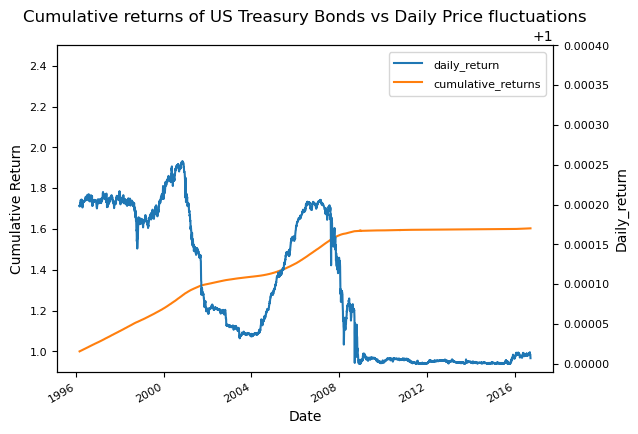

In [26]:

plt.figure();
ax = USTB[['daily_return', 'cumulative_returns']].plot(secondary_y = ['daily_return'], mark_right= False, fontsize = 8)
ax.set_ylabel('Cumulative Return');
ax.set_ylim((0.9,2.5))
ax.right_ax.set_ylim((1-0.00001,1.0004))
ax.right_ax.set_ylabel('Daily_return');

plt.setp(ax.get_legend().get_texts(), fontsize=8)
plt.title('Cumulative returns of US Treasury Bonds vs Daily Price fluctuations')

### Seeing the return of the S&P500 in a given timeframe
- aim is to have a fucntion, where you give it a starting date and an amount
- it spits out what the amount would have gone to under the snp500 in that time , also the gross % gain

source: https://www.kaggle.com/datasets/henryhan117/sp-500-historical-data?resource=download

In [28]:
snp = pd.read_csv("SPX.csv")

In [29]:
snp.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1927-12-30,17.660000,17.660000,17.660000,17.660000,17.660000,0
1,1928-01-03,17.760000,17.760000,17.760000,17.760000,17.760000,0
2,1928-01-04,17.719999,17.719999,17.719999,17.719999,17.719999,0
3,1928-01-05,17.549999,17.549999,17.549999,17.549999,17.549999,0
4,1928-01-06,17.660000,17.660000,17.660000,17.660000,17.660000,0


In [30]:
# only run this cell once
snp = snp[['Date', 'Open', 'Volume']].copy()
snp['Date'] = pd.to_datetime(snp['Date'])
snp.set_index('Date', inplace = True)
snp.head()

,Open,Volume
Date,,
1927-12-30,17.660000,0
1928-01-03,17.760000,0
1928-01-04,17.719999,0
1928-01-05,17.549999,0
1928-01-06,17.660000,0


In [31]:
snp = snp["1996-02-28":"2016-09-23"]

<Axes: xlabel='Date'>

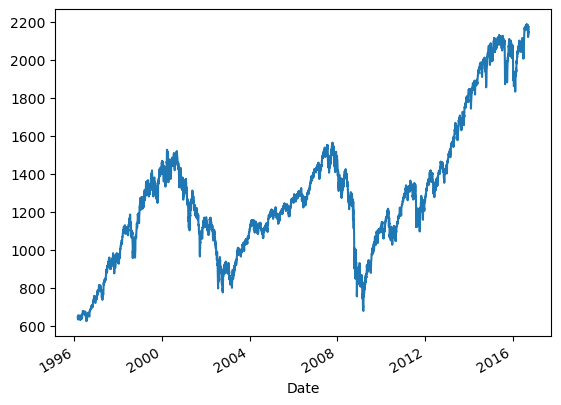

In [32]:
snp['Open'].plot()

In [33]:
snp['Open_adj'] = snp['Open'] / 6.47239990
snp['Growth_Percentage'] = snp['Open'] / 647.239990 # to find cumulative return

In [34]:
snp.head()

,Open,Volume,Open_adj,Growth_Percentage
Date,,,,
1996-02-28,647.239990,447790000,100.000000,1.000000
1996-02-29,644.750000,453170000,99.615291,0.996153
1996-03-01,640.429993,471480000,98.947841,0.989478
1996-03-04,644.369995,417270000,99.556579,0.995566
1996-03-05,650.809998,445700000,100.551574,1.005516


In [35]:
def snp_invest(start, end, amount):

    # if the dates are a weekend for example it goes back to the last open day
    start = snp.index.asof(start)
    end = snp.index.asof(end)
    
    stocks = amount / snp.loc[start]['Open'] # e.g 100 / 600 = 1/6 of a stock
    final_amount = snp.loc[end]['Open'] * stocks 
    CR = ((final_amount / amount)) 

    # print (f"{amount:.2f} grew to {final_amount:.2f}")
    # print (f"{snp.loc[start]['Open']} was the value of the snp in {start}")
    # print (f"{snp.loc[end]['Open']} was the value of the snp in {end}")
    # print (f"cumulative return was {CR:.2f}")

    return (final_amount, CR) # cumulative return
    

In [36]:
snp_invest("2000-02-28","2016-09-23", 200)

(325.98698977755805, 1.6299349488877903)

Text(0.5, 1.0, 'S&P 500 stock price vs cumulative return')

<Figure size 640x480 with 0 Axes>

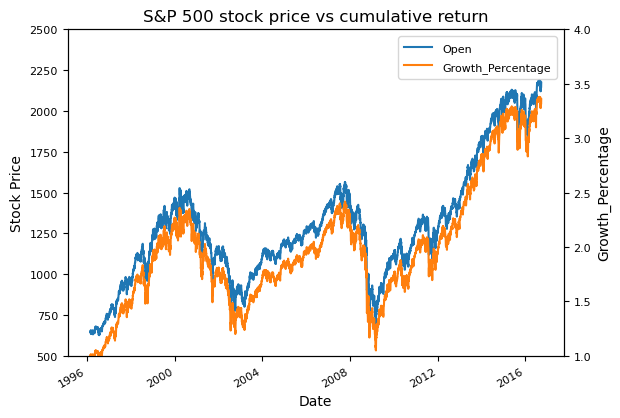

In [37]:
plt.figure();
ax = snp[['Open', 'Growth_Percentage']].plot(secondary_y = ['Growth_Percentage'], mark_right= False, fontsize = 8)
ax.set_ylabel('Stock Price');
ax.set_ylim((500,2500))
ax.right_ax.set_ylim((1,4))
ax.right_ax.set_ylabel('Growth_Percentage');

plt.setp(ax.get_legend().get_texts(), fontsize=8)
plt.title('S&P 500 stock price vs cumulative return')

### Plotting S&P500 returns vs USTB returns 

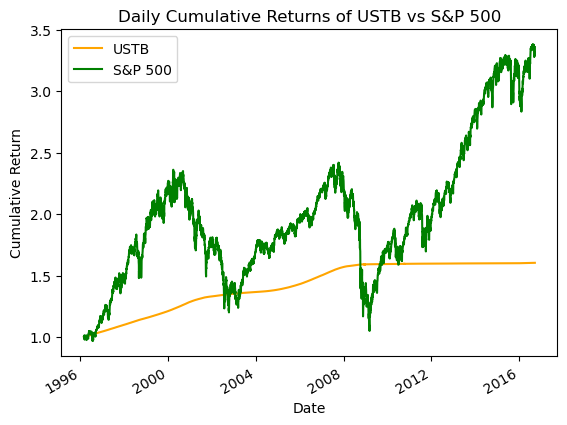

In [39]:
plt.figure()
USTB['cumulative_returns'].plot(label='USTB', color = 'orange')
snp['Growth_Percentage'].plot(label='S&P 500', color = 'green')
plt.legend()
plt.ylabel('Cumulative Return')
plt.title('Daily Cumulative Returns of USTB vs S&P 500')


plt.savefig("Daily Cumulative Returns of USTB vs S&P 500", dpi=600, transparent=True, bbox_inches='tight')

plt.show()

### Investing Rationally... 
- they care about efficiency, getting the maximum return per unit of risk
- this means maximising sharpe ration (return / risk)
- we need to maxmimise (Rp - Rf)/ std(p)
- risk free is defined as the return from the USTB.
- Rp is portfolio return (return of the stock)
- std(p) is the standard devidation (of the stock)
- so for each stock the sharpe ratio is calculated and only the top 10 stocks are selected to be invested in


In [41]:
def rational_invest(start, end, df1): # df is your daily stock prices # lets say start is today, so end is when you sell

    #final = "2016-09-23"
    #begin = "1996-02-28"
    
    end = df1.index.asof(end)
    start = df1.index.asof(start)

    lookback_period = start - pd.DateOffset(years = 5)
    begin = lookback_period

    returns = df1.loc[begin:start]
    percent_returns = returns.pct_change().dropna()
    
    risk_free =  USTB[begin:start].copy()
    daily_rf = (risk_free['daily_return'] -1)
    rf_mean = daily_rf.mean()

    
    sharpe = (percent_returns.mean() - rf_mean) / percent_returns.std() # this is sharpe / stock


    top10 = sharpe.sort_values(ascending=False).head(10).index.tolist()
    
    #print (top10)


    return (invest(top10, start, end, 100, "equal", df1), top10)    


Example output

In [43]:
rational_invest("2005-05-28", "2016-09-23", df)

((336.6714, 3.3667),
 ['GGP', 'VTR', 'DVA', 'HFC', 'URBN', 'SPG', 'MAC', 'FRT', 'REG', 'PSA'])

### Graphing Cumulative returns
The following series of graphs, visualise the return you would expect from investing in the S&P500 (whilst maximising the sharpe ratio) in a given year. For example investing with this strategy in 2002 would result in a 10x return by 2016. As such the lower returns of years closer to 2016 is expected as there is less time that has passed between the intial investment and evaluation of the assests in 2016. This explains the decreasing trend of the graph.

These series of graphs were not included in the final presentation as I believe the showing the cumulative increasing from the start date (1996) until 2016 is a more powerful visualisation. Rather than showing the returns of having invested in each year.

In [45]:
biweekly = pd.DataFrame()
for date in pd.date_range(start="1997-01-01", end="2016-09-23", freq="2W"):
    
    date_to_invest = date.strftime('%Y-%m-%d')
    label = date.strftime('%d %b %Y')
    growth, top10 = rational_invest(date_to_invest, "2016-09-23", df)
    no_risk = rf(date_to_invest, "2016-09-23")
    snp500 = snp_invest(date_to_invest, "2016-09-23", 100)
    
    biweekly.loc[label, "Top10 stocks"] = str(top10)
    biweekly.loc[label, "Maximising Sharpe Ratio"] = growth[1]
    biweekly.loc[label, "USTB"] = no_risk
    biweekly.loc[label, "S&P500"] = snp500[1]

biweekly.head()

,Top10 stocks,Maximising Sharpe Ratio,USTB,S&P500
05 Jan 1997,"['NFX', 'SPXC', 'JBL', 'INTC', 'MTW', 'COO', '...",7.2352,1.534250,2.948793
19 Jan 1997,"['HOT', 'SPXC', 'USB', 'WDC', 'JBL', 'NFX', 'I...",6.0500,1.531117,2.823371
02 Feb 1997,"['USB', 'HOT', 'SPXC', 'INTC', 'WDC', 'JBL', '...",5.4464,1.528289,2.771453
16 Feb 1997,"['USB', 'SPXC', 'HOT', 'COO', 'ZION', 'INTC', ...",5.6914,1.525179,2.677059
02 Mar 1997,"['USB', 'SPXC', 'COO', 'HOT', 'VNO', 'AES', 'R...",6.3679,1.522375,2.733457


In [46]:
print(biweekly.loc['05 Jan 1997', 'Top10 stocks'])

['NFX', 'SPXC', 'JBL', 'INTC', 'MTW', 'COO', 'HOT', 'REG', 'AVB', 'WDC']


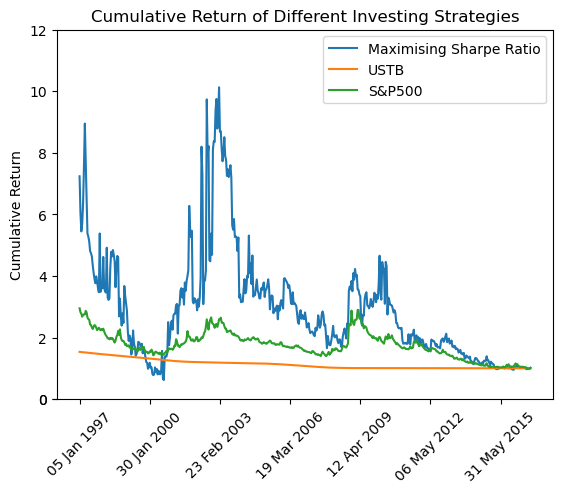

In [47]:
biweekly.plot()
plt.xticks(range(0, len(biweekly), 80), biweekly.index[::80], rotation=45);
plt.yticks(list(plt.yticks()[0]) + [0]);

plt.ylabel('Cumulative Return')

plt.title('Cumulative Return of Different Investing Strategies')
plt.savefig("Cumulative Returns of USTB vs S&P 500", dpi=600, transparent=True, bbox_inches='tight')


In [48]:
# DONT RUN IT TAKES FOREVER 
# DONT RUN
# daily = pd.DataFrame()
# for date in pd.date_range(start="1997-01-01", end="2016-09-23", freq="1D"):
    
#     date_to_invest = date.strftime('%Y-%m-%d')
#     label = date.strftime('%d %b %Y')
#     growth, top10 = rational_invest(date_to_invest, "2016-09-23", df)
#     no_risk = rf(date_to_invest, "2016-09-23")
#     snp500 = snp_invest(date_to_invest, "2016-09-23", 100)
    
#     daily.loc[label, "Top10 stocks"] = str(top10)
#     daily.loc[label, "Maximising Sharpe Ratio"] = growth[1]
#     daily.loc[label, "USTB"] = no_risk
#     daily.loc[label, "S&P500"] = snp500[1]


# daily

In [49]:
#print(daily.loc['05 Jan 1997', 'Top10 stocks'])

In [50]:
# daily.plot()
# plt.xticks(range(0, len(daily), 1200), daily.index[::1200], rotation=45);
# plt.yticks(list(plt.yticks()[0]) + [0]);

# plt.ylabel('Cumulative Return')

# plt.title('Daily Cumulative Return of Different Investing Strategies')
# plt.savefig("Daily Cumulative Returns of USTB vs S&P 500", dpi=600, transparent=True, bbox_inches='tight')
# # maximising sharpe chose top 10

The difference here is that this rational invest allows for the lookback years to be changed

In [52]:
def new_rational_invest(start, end, df1, stocks, lookback_years): # df is your daily stock prices # lets say start is today, so end is when you sell
    
    end = df1.index.asof(end)
    start = df1.index.asof(start)

    lookback_period = start - pd.DateOffset(days = int(lookback_years) * 365.25)
    begin = lookback_period

    returns = df1.loc[begin:start]
    percent_returns = returns.pct_change().dropna()
    
    risk_free =  USTB[begin:start].copy()
    daily_rf = (risk_free['daily_return'] -1)
    rf_mean = daily_rf.mean()

    
    sharpe = (percent_returns.mean() - rf_mean) / percent_returns.std() # this is sharpe / stock


    companies = sharpe.sort_values(ascending=False).head(stocks).index.tolist()
    



    return (invest(companies, start, end, 100, "equal", df1), companies)

    
    #return (invest(list of stocks, start, end, amount, "equal", df1),top10)
    


### Finding the optimal lookback yeras and top X stocks by sharpe ratio to take

In [54]:
def sensitivity_analysis(df1, start="1997-01-01", end="2016-09-23", 
                          stock_range=range(5, 45, 5), 
                          lookback_range=np.arange(0.5, 10.5, 0.5)):
    
    end = df1.index.asof(end)
    start = df1.index.asof(start)
    results = pd.DataFrame()
    total = len(stock_range) * len(lookback_range)
    count = 0

    for n_stocks in stock_range:
        for lookback in lookback_range:
            count += 1
            #print(f"Running {count}/{total} — stocks: {n_stocks}, lookback: {lookback} yrs")
            returns_list = []

            for date in pd.date_range(start=start, end=end, freq="1YE"):
                date_to_invest = date.strftime('%Y-%m-%d')
                try:
                    growth, companies = new_rational_invest(date_to_invest, end, df, n_stocks, lookback)
                    returns_list.append(growth[1])
                except Exception as e:
                    print(f"  Skipping {date_to_invest}: {type(e).__name__}: {e}")
                    continue

            if len(returns_list) == 0:
                continue

            returns_series = pd.Series(returns_list)
            label = f"stocks_{n_stocks}_lookback_{lookback}"
            results.loc[label, "n_stocks"] = n_stocks
            results.loc[label, "lookback_years"] = lookback
            results.loc[label, "mean_return"] = returns_series.mean()
            results.loc[label, "volatility"] = returns_series.std()
            results.loc[label, "sharpe"] = (returns_series.mean() / returns_series.std())

    return results

In [55]:
trends = pd.read_csv("trends in maxmimsing sharpe ratio.csv")

In [56]:
# trends = sensitivity_analysis(df, "1997-01-01", "2016-09-23", 
#                           range(5, 205, 10), 
#                           np.arange(1, 10, 1))

In [57]:
trends.describe()

,n_stocks,lookback_years,mean_return,volatility,sharpe
count,159.000000,159.000000,159.000000,159.000000,159.000000
mean,22.610063,5.279874,3.500865,2.564043,1.433819
std,11.443815,2.876460,0.812995,1.016877,0.224895
min,5.000000,0.500000,2.788775,1.416669,0.898324
25%,15.000000,3.000000,3.108730,1.999001,1.297390
50%,25.000000,5.500000,3.288905,2.197803,1.474182
75%,32.500000,7.750000,3.471307,2.791247,1.590610
max,40.000000,10.000000,9.100525,9.088675,2.003140


In [58]:
# only done first time
#trends.to_csv("trends in maxmimsing sharpe ratio.csv")

### Testing a dynamic investing strategy, where we recalculate the best stocks by sharpe ratio each X years and reinvest
- given a starting year, find top X amount by max sharpe ratio
- invest your $100 equally into this for the year
- in X years time recalculate the top 10 by max sharpe ratio
- if any same then keep
- for those that are not the same you want to sell and invest in them equally with the money made from selling



In [60]:
def rolling_sharpe_invest(start, end, df1, n_stocks, lookback_years, rebalance_freq_years=1):
    
    #dates = pd.date_range(start=start, end=end, freq=f'{rebalance_freq_years}YE')
    dates = pd.date_range(start=start, end=end, freq=pd.DateOffset(years=rebalance_freq_years))
    
    portfolio = {}   # {company: shares}
    cash = 100.0
    current_holdings_value = 0
    records = []

    for i, date in enumerate(dates):
        date_str = date.strftime('%Y-%m-%d')
        next_date = dates[i+1] if i+1 < len(dates) else pd.Timestamp(end)
        next_str = next_date.strftime('%Y-%m-%d')
        
        current_date = df1.index.asof(date_str)
        
        # get new top n stocks by sharpe
        lookback_begin = current_date - pd.DateOffset(days=int(lookback_years * 365.25))
        returns = df1.loc[lookback_begin:current_date].pct_change().dropna()
        risk_free = USTB[lookback_begin:current_date].copy()
        rf_mean = (risk_free['daily_return'] - 1).mean()
        sharpe = (returns.mean() - rf_mean) / returns.std()
        new_top = sharpe.sort_values(ascending=False).head(n_stocks).index.tolist()
        
        # value existing portfolio at current prices
        portfolio_value = sum(
            shares * df1.loc[current_date, company]
            for company, shares in portfolio.items()
        ) if portfolio else cash
        
        # figure out what to sell (held but not in new top)
        to_sell = [c for c in portfolio if c not in new_top]
        to_keep = [c for c in portfolio if c in new_top]
        
        # sell unwanted stocks
        sold_cash = sum(
            portfolio[c] * df1.loc[current_date, c]
            for c in to_sell
        )
        for c in to_sell:
            del portfolio[c]
        
        # total cash available to deploy (sold + any uninvested cash)
        available_cash = sold_cash + cash
        cash = 0
        
        # buy new stocks equally with available cash
        to_buy = [c for c in new_top if c not in to_keep]
        if to_buy:
            split = available_cash / len(to_buy)
            for company in to_buy:
                price = df1.loc[current_date, company]
                shares = split / price
                portfolio[company] = portfolio.get(company, 0) + shares
        else:
            cash = available_cash  # nothing to buy, hold cash
        
        records.append({
            'date': date.strftime('%d %b %Y'),
            'portfolio_value': round(portfolio_value, 4),
            'holdings': list(portfolio.keys()),
            'sold': to_sell,
            'bought': to_buy,
            'n_kept': len(to_keep)
        })

    # final value at end date
    end_date = df1.index.asof(end)
    final_value = sum(
        shares * df1.loc[end_date, company]
        for company, shares in portfolio.items()
    ) + cash
    
    records.append({
        'date': end,
        'portfolio_value': round(final_value, 4),
        'holdings': list(portfolio.keys()),
        'sold': [], 'bought': [], 'n_kept': len(portfolio)
    })

    results_df = pd.DataFrame(records)
    # print(f"Start: $100 → End: ${round(final_value, 2)}")
    # print(f"Total return: {round(final_value, 4)}x")
    # print (f"Cumulative return: {round(final_value / 100,2)}X")

    #return (results_df)
    return (final_value / 100)

The function above can return the results df, which was used for ensuring the code is doing as expected. It should be used to return the final value by default.

In [62]:
results = rolling_sharpe_invest("1997-01-01", "2016-09-23", df, n_stocks=10, lookback_years=5, rebalance_freq_years=6)

In [63]:
results # 21x cumulative return (this is shown later in the final graph)

21.985424710290143

### New sharpe invest also records a timeline of the returns periodically

In [65]:
def new_rolling_sharpe_invest(start, end, df1, n_stocks, lookback_years, rebalance_freq_years=1):
    
    dates = pd.date_range(start=start, end=end, freq=pd.DateOffset(years=rebalance_freq_years))
    monthly_dates = pd.date_range(start=start, end=end, freq="1ME")
    
    portfolio = {}
    cash = 100.0
    records = []
    timeline = {}

    for i, date in enumerate(dates):
        date_str = date.strftime('%Y-%m-%d')
        next_date = dates[i+1] if i+1 < len(dates) else pd.Timestamp(end)
        current_date = df1.index.asof(date_str)
        
        lookback_begin = current_date - pd.DateOffset(days=int(lookback_years * 365.25))
        returns = df1.loc[lookback_begin:current_date].pct_change().dropna()
        risk_free = USTB[lookback_begin:current_date].copy()
        rf_mean = (risk_free['daily_return'] - 1).mean()
        sharpe = (returns.mean() - rf_mean) / returns.std()
        new_top = sharpe.sort_values(ascending=False).head(n_stocks).index.tolist()
        
        portfolio_value = sum(
            shares * df1.loc[current_date, company]
            for company, shares in portfolio.items()
        ) if portfolio else cash
        
        to_sell = [c for c in portfolio if c not in new_top]
        to_keep = [c for c in portfolio if c in new_top]
        
        sold_cash = sum(portfolio[c] * df1.loc[current_date, c] for c in to_sell)
        for c in to_sell:
            del portfolio[c]
        
        available_cash = sold_cash + cash
        cash = 0
        
        to_buy = [c for c in new_top if c not in to_keep]
        if to_buy:
            split = available_cash / len(to_buy)
            for company in to_buy:
                price = df1.loc[current_date, company]
                shares = split / price
                portfolio[company] = portfolio.get(company, 0) + shares
        else:
            cash = available_cash

        records.append({
            'date': date.strftime('%d %b %Y'),
            'portfolio_value': round(portfolio_value, 4),
            'holdings': list(portfolio.keys()),
            'sold': to_sell,
            'bought': to_buy,
            'n_kept': len(to_keep)
        })

        # snapshot portfolio value at each monthly date in this rebalance window
        window_dates = monthly_dates[(monthly_dates >= date) & (monthly_dates < next_date)]
        for m in window_dates:
            m_date = df1.index.asof(m.strftime('%Y-%m-%d'))
            val = sum(shares * df1.loc[m_date, c] for c, shares in portfolio.items()) + cash
            timeline[m.strftime('%d %b %Y')] = round(val, 4)

    end_date = df1.index.asof(end)
    final_value = sum(shares * df1.loc[end_date, c] for c, shares in portfolio.items()) + cash
    timeline[end] = round(final_value, 4)

    records.append({
        'date': end,
        'portfolio_value': round(final_value, 4),
        'holdings': list(portfolio.keys()),
        'sold': [], 'bought': [], 'n_kept': len(portfolio)
    })

    results_df = pd.DataFrame(records)
    timeline_series = pd.Series(timeline)
    
    return (final_value/100, results_df, timeline_series)

In [66]:
rolling_sharpe_invest("1998-01-01", "2016-09-23", df, n_stocks=10, lookback_years=5, rebalance_freq_years=6)

7.949198728062485

In [67]:
new_rolling_sharpe_invest("1998-01-01", "2016-09-23", df, n_stocks=10, lookback_years=5, rebalance_freq_years=6)

(7.949198728062485,
           date  portfolio_value  \
 0  01 Jan 1998         100.0000   
 1  01 Jan 2004         151.1078   
 2  01 Jan 2010         223.4281   
 3  01 Jan 2016         828.4794   
 4   2016-09-23         794.9199   
 
                                             holdings  \
 0  [COO, USB, SPXC, MTB, HOT, CMA, NTRS, AES, VNO...   
 1  [VAR, GGP, LH, HAR, CHK, ESS, UNH, MAA, EQT, UDR]   
 2  [AAPL, MNST, ESRX, SWN, NEU, CELG, ALXN, WDC, ...   
 3  [LMT, HD, KR, MO, AGN, REGN, HRL, NOC, ORLY, ABC]   
 4  [LMT, HD, KR, MO, AGN, REGN, HRL, NOC, ORLY, ABC]   
 
                                                 sold  \
 0                                                 []   
 1  [COO, USB, SPXC, MTB, HOT, CMA, NTRS, AES, VNO...   
 2  [VAR, GGP, LH, HAR, CHK, ESS, UNH, MAA, EQT, UDR]   
 3  [AAPL, MNST, ESRX, SWN, NEU, CELG, ALXN, WDC, ...   
 4                                                 []   
 
                                               bought  n_kept  
 0  [COO, 

### Testing to see if the function does what it is supposed to by manually looking at what the return should be in each period

In [69]:
rational_invest("2015-1-1","2016-1-1", df)

((115.9467, 1.1595),
 ['MO', 'AGN', 'AZO', 'ORLY', 'LB', 'SHW', 'HSY', 'HD', 'ROST', 'ABC'])

In [70]:
rational_invest("1997-01-01","2016-09-23", df)

((796.7883, 7.9679),
 ['SPXC', 'HOT', 'NFX', 'MTW', 'AVB', 'COO', 'JBL', 'VNO', 'REG', 'INTC'])

In [71]:
print ((rolling_sharpe_invest("2009-01-01", "2016-09-23", df, n_stocks=10, lookback_years=5, rebalance_freq_years=6)))
(rational_invest("2009-01-01","2016-09-23", df))

4.93719377239315


((411.0531, 4.1105),
 ['MNST', 'AAPL', 'SWN', 'CELG', 'RRC', 'MCD', 'ALXN', 'GILD', 'ESRX', 'PBCT'])

In [72]:
rational_invest("1997-12-31", "2002-12-31", df)

((101.7646, 1.0176),
 ['COO', 'USB', 'SPXC', 'MTB', 'HOT', 'CMA', 'NTRS', 'AES', 'VNO', 'VMC'])

In [73]:
rational_invest("2002-12-31","2007-12-31", df)

((277.0879, 2.7709),
 ['DISH', 'KSU', 'CELG', 'VAR', 'AJG', 'LH', 'BIIB', 'TSCO', 'QCOM', 'SYK'])

### Graphing the return of rolling sharpe vs static sharpe ratio

In [75]:
# takes a short while to run
yearly = pd.DataFrame()
for date in pd.date_range(start="1997-01-01", end="2016-09-23", freq="1ME"):
    
    date_to_invest = date.strftime('%Y-%m-%d')
    label = date.strftime('%d %b %Y')
    
    growth, companies = new_rational_invest(date_to_invest, "2016-09-23", df,10,5)
    rolling_sharpe = rolling_sharpe_invest(date_to_invest, "2016-09-23", df, n_stocks=10, lookback_years=5, rebalance_freq_years=6)
    no_risk = rf(date_to_invest, "2016-09-23")
    snp500 = snp_invest(date_to_invest, "2016-09-23", 100)
    yearly.loc[label, "companies"] = str(companies)
    yearly.loc[label, "Maximising Sharpe Ratio"] = growth[1]
    yearly.loc[label, "Sharpe Ratio Rolling Average"] = rolling_sharpe
    yearly.loc[label, "USTB"] = no_risk
    yearly.loc[label, "S&P500"] = snp500[1]

print (yearly['Maximising Sharpe Ratio'].mean())
print (yearly['Maximising Sharpe Ratio'].std())
print (yearly['Maximising Sharpe Ratio'].mean() / yearly['Maximising Sharpe Ratio'].std())

print (yearly["Sharpe Ratio Rolling Average"].mean())
print (yearly["Sharpe Ratio Rolling Average"].std())
print (yearly["Sharpe Ratio Rolling Average"].mean() / yearly['Maximising Sharpe Ratio'].std())

yearly

2.9503402542372883
1.873709700837085
1.5745983771761525
3.701596197512908
2.984740662363901
1.9755441282388673


,companies,Maximising Sharpe Ratio,Sharpe Ratio Rolling Average,USTB,S&P500
31 Jan 1997,"['USB', 'HOT', 'SPXC', 'INTC', 'WDC', 'JBL', '...",5.4464,17.867819,1.528601,2.771453
28 Feb 1997,"['USB', 'SPXC', 'COO', 'HOT', 'VNO', 'AES', 'R...",6.3679,17.258360,1.522691,2.733457
31 Mar 1997,"['SPXC', 'USB', 'VNO', 'COO', 'JBL', 'REG', 'A...",7.7719,17.086488,1.516326,2.808304
30 Apr 1997,"['SPXC', 'USB', 'MSFT', 'VNO', 'AES', 'INTC', ...",6.0446,13.087528,1.509317,2.736969
31 May 1997,"['SPXC', 'VNO', 'USB', 'AES', 'MSFT', 'JBL', '...",5.8351,8.607808,1.502481,2.574744
...,...,...,...,...,...
30 Apr 2016,"['LMT', 'HD', 'MO', 'NOC', 'ORLY', 'NI', 'STZ'...",1.0325,1.032521,1.001174,1.048976
31 May 2016,"['LMT', 'HD', 'NOC', 'ORLY', 'MO', 'NI', 'FISV...",1.0276,1.027580,1.000957,1.034836
30 Jun 2016,"['LMT', 'MO', 'NI', 'HD', 'NOC', 'FISV', 'STZ'...",0.9822,0.982244,1.000715,1.048293
31 Jul 2016,"['LMT', 'HD', 'MO', 'NOC', 'ORLY', 'FISV', 'NI...",0.9740,0.973994,1.000466,1.002056


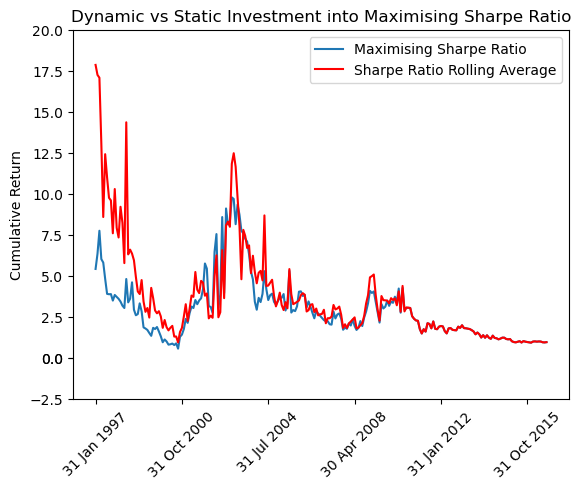

In [76]:
yearly[['Maximising Sharpe Ratio', 'Sharpe Ratio Rolling Average']].plot(color=['#1f77b4', 'red'])
plt.xticks(range(0, len(yearly), 45), yearly.index[::45], rotation=45);
plt.yticks(list(plt.yticks()[0]) + [0]);

plt.ylabel('Cumulative Return')

plt.title('Dynamic vs Static Investment into Maximising Sharpe Ratio')
plt.savefig("Dynamic vs Static Investment into Maximising Sharpe Ratio", dpi=600, transparent=True, bbox_inches='tight')

### Graphing the cumulative growth of investing from the start to the end 
- so for every month you've got the cumulative return at that time

In [78]:
USTB

,daily_return,cumulative_returns
Date,,
1996-02-28,1.000199,1.000199
1996-02-29,1.000199,1.000398
1996-03-01,1.000198,1.000596
1996-03-04,1.000199,1.000795
1996-03-05,1.000199,1.000994
...,...,...
2016-09-19,1.000012,1.603254
2016-09-20,1.000012,1.603273
2016-09-21,1.000009,1.603287


In [79]:
def rf_cumulative(end): # we need a function here rather than just returning USTB["cumulative_returns"].loc[end] as sometimes the end date is not in the dataframe (e.g for a weekend or public holiday)
    end = USTB.index.asof(end)
    return USTB["cumulative_returns"].loc[end]

rf_cumulative("2002-09-23") # E.g the value of USTB in 2002-09-23 was 1.3x their value in the beginning of the dataframe (1996)

1.3471501851563796

In [80]:
start = "1997-01-01"
end = "2016-09-23"

_, companies = new_rational_invest(start, end, df, 10, 5)

timeline = pd.DataFrame()
for date in pd.date_range(start=start, end=end, freq="1ME"):
    date_str = date.strftime('%Y-%m-%d')
    label = date.strftime('%d %b %Y')
    
    #timeline.loc[label, 'Rolling Sharpe'] = rolling_sharpe_invest(start, date_str, df, n_stocks=10, lookback_years=5, rebalance_freq_years=6) * 100
    timeline.loc[label, 'Maximising Sharpe Ratio'] = invest(companies, start, date_str, 100, "equal", df)[0]
    timeline.loc[label, 'S&P500'] = snp_invest(start, date_str, 100)[0]
    timeline.loc[label, 'USTB'] = rf_cumulative(date_str)

timeline = timeline / 100 # to get cumulative return (as amount is 100)
timeline["USTB"] = timeline["USTB"] * 100 # without this USTB returns are 0.010491 for example when they should be 1.04%

timeline.tail()

,Maximising Sharpe Ratio,S&P500,USTB
30 Apr 2016,7.259284,2.748319,1.601430
31 May 2016,7.528285,2.785872,1.601799
30 Jun 2016,7.721858,2.750109,1.602180
31 Jul 2016,8.076911,2.877005,1.602563
31 Aug 2016,8.011826,2.883279,1.603001


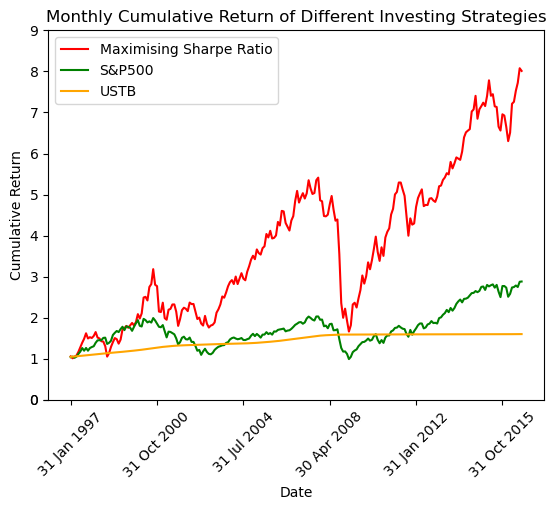

In [81]:
timeline.plot(color = ['red', 'green', 'orange',])

plt.xticks(range(0, len(timeline), 45), timeline.index[::45], rotation=45);
plt.yticks(list(plt.yticks()[0]) + [0]);
plt.xlabel('Date')

plt.ylabel('Cumulative Return')

plt.title('Monthly Cumulative Return of Different Investing Strategies')
plt.savefig("Monthly Cumulative Return of Different Investing Strategies", dpi=600, transparent=True, bbox_inches='tight')

### Seeing the variance cumulative return based on the number of years you look back on
- maximising sharpe ratio in red vs blue for all the differnt year look back times


In [83]:
start = "1997-01-01"
end = "2016-09-23"
_, companies = new_rational_invest(start, end, df, 10, 5)

timeline_cumulative_returns = pd.DataFrame()

for freq in [3, 4, 5, 6, 7, 8]:
    _, _, tl = new_rolling_sharpe_invest(start, end, df, n_stocks=10, lookback_years=5, rebalance_freq_years=freq)
    timeline_cumulative_returns[f'Rolling Sharpe every {freq} years'] = tl  # convert to dollars

for date in pd.date_range(start=start, end=end, freq="1ME"):
    date_str = date.strftime('%Y-%m-%d')
    label = date.strftime('%d %b %Y')
    timeline_cumulative_returns.loc[label, 'Maximising Sharpe Ratio'] = invest(companies, start, date_str, 1, "equal", df)[0] * 100


timeline_cumulative_returns = timeline_cumulative_returns / 100

In [84]:
timeline_cumulative_returns

,Rolling Sharpe every 3 years,Rolling Sharpe every 4 years,Rolling Sharpe every 5 years,Rolling Sharpe every 6 years,Rolling Sharpe every 7 years,Rolling Sharpe every 8 years,Maximising Sharpe Ratio
31 Jan 1997,1.059633,1.059633,1.059633,1.059633,1.059633,1.059633,1.0596
28 Feb 1997,1.013791,1.013791,1.013791,1.013791,1.013791,1.013791,1.0138
31 Mar 1997,1.055722,1.055722,1.055722,1.055722,1.055722,1.055722,1.0557
30 Apr 1997,1.079989,1.079989,1.079989,1.079989,1.079989,1.079989,1.0800
31 May 1997,1.169250,1.169250,1.169250,1.169250,1.169250,1.169250,1.1692
...,...,...,...,...,...,...,...
31 May 2016,6.341124,8.010192,6.326420,20.979296,12.563744,14.887389,7.5283
30 Jun 2016,6.613631,7.689097,6.286637,21.886228,12.121521,14.584084,7.7219
31 Jul 2016,6.929777,8.217618,6.471303,22.934983,12.637700,15.546693,8.0769
31 Aug 2016,6.704096,7.749752,6.344939,22.175204,12.470484,14.613684,8.0118


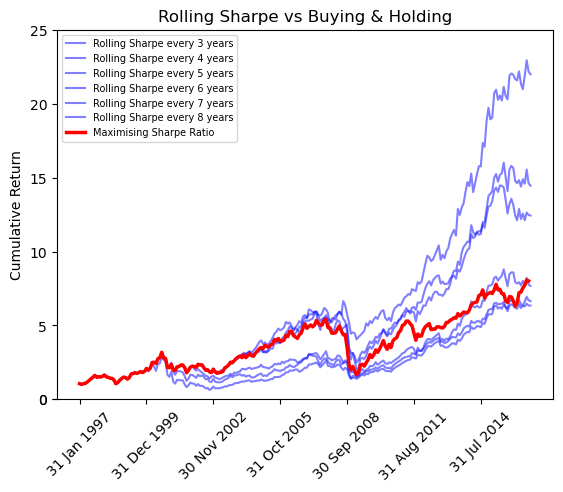

In [86]:
rolling_cols = [c for c in timeline_cumulative_returns.columns if c.startswith('Rolling')]
fig, ax = plt.subplots()
for col in rolling_cols:
    timeline_cumulative_returns[col].plot(ax=ax, color='blue', alpha=0.5, label=col)
timeline_cumulative_returns['Maximising Sharpe Ratio'].plot(ax=ax, color='red', label='Maximising Sharpe Ratio', linewidth = 2.5)

plt.xticks(range(0, len(timeline_cumulative_returns), 35), timeline_cumulative_returns.index[::35], rotation=45)
plt.yticks(list(plt.yticks()[0]) + [0])
plt.ylabel('Cumulative Return')
plt.ylim(bottom=0)
plt.title('Rolling Sharpe vs Buying & Holding')
plt.legend(fontsize=7)
plt.savefig("rolling_vs_static", dpi=600, transparent=True, bbox_inches='tight')

The purpose of the above graph is to demonstrate that no 'optimal' lookback period was determined, this will be different for each dataset. Here looking back every 6 years receives the best results of 21x returns, whilst looking back 5 years receives the worst result of 6x returns.

Additionally with the current approach of selling stocks that are not in the top 10 rolling sharpe, this may result in selling stocks at a low and buying new stocks at a high. 

More optimal of course would be to predict stocks with a high sharpe ratio and invest when they are low. 

### Earlier we defined risk as the standard deviation in the returns of the stock / unit of time (e.g daily returns), so now I will find risk of each of these approaches

In [106]:
# first I will do this for yearly risk vs cumulative returns (each member of our group is doing this and comparing)

daily_returns = timeline_cumulative_returns.pct_change().dropna()
daily_returns.index = pd.to_datetime(daily_returns.index, format='mixed')

timeline_daily_returns = timeline.pct_change().dropna()
timeline_daily_returns.index = pd.to_datetime(timeline_daily_returns.index, format='mixed')

yearly_vol_mean = daily_returns.resample('YE').std().mean()
timeline_yearly_vol_mean = timeline_daily_returns.resample('YE').std().mean()

all_yearly_vol = pd.concat([yearly_vol_mean, timeline_yearly_vol_mean])

cumulative_returns = pd.concat([
    timeline_cumulative_returns.tail(1).squeeze(),
    timeline.tail(1).squeeze()
])

full_summary_yearly = pd.DataFrame({
    'Cumulative Return': cumulative_returns,
    'Yearly Volatility (mean)': all_yearly_vol
})

print(full_summary_yearly)

                              Cumulative Return  Yearly Volatility (mean)
Rolling Sharpe every 3 years           6.640792                  0.066244
Rolling Sharpe every 4 years           7.678180                  0.065824
Rolling Sharpe every 5 years           6.346119                  0.057021
Rolling Sharpe every 6 years          21.985425                  0.057666
Rolling Sharpe every 7 years          12.437508                  0.056353
Rolling Sharpe every 8 years          14.452369                  0.066763
Maximising Sharpe Ratio                     NaN                  0.064609
Maximising Sharpe Ratio                8.011826                  0.064721
S&P500                                 2.883279                  0.041092
USTB                                   1.603001                  0.000277


C:\Users\Donald\AppData\Local\Temp\ipykernel_16008\316821890.py:3: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  daily_returns = timeline_cumulative_returns.pct_change().dropna()


In [114]:
full_summary_yearly

,Cumulative Return,Yearly Volatility (mean)
Rolling Sharpe every 3 years,6.640792,0.066244
Rolling Sharpe every 4 years,7.678180,0.065824
Rolling Sharpe every 5 years,6.346119,0.057021
Rolling Sharpe every 6 years,21.985425,0.057666
Rolling Sharpe every 7 years,12.437508,0.056353
Rolling Sharpe every 8 years,14.452369,0.066763
Maximising Sharpe Ratio,8.011826,0.064721
S&P500,2.883279,0.041092
USTB,1.603001,0.000277


In [112]:
full_summary_yearly = full_summary_yearly.dropna()
full_summary_yearly.to_csv('sharpe_ratio_returns_and_volatility.csv')

In [116]:
# now I will use daily returns, which is more accurate
timeline_cumulative_returns = timeline_cumulative_returns.ffill() # replacing NA values with the last known value
daily_returns = timeline_cumulative_returns.pct_change().dropna()
volatility = daily_returns.std()

In [118]:
volatility

Rolling Sharpe every 3 years    0.079098
Rolling Sharpe every 4 years    0.072348
Rolling Sharpe every 5 years    0.062251
Rolling Sharpe every 6 years    0.061126
Rolling Sharpe every 7 years    0.061794
Rolling Sharpe every 8 years    0.073037
Maximising Sharpe Ratio         0.071412
dtype: float64

In [120]:
timeline_daily_returns = timeline.pct_change().dropna() # recall timeline was the data used to graph the USTB, S&P500 and Static Maximising Sharpe Ratio.
timeline_daily_returns.std()

Maximising Sharpe Ratio    0.071560
S&P500                     0.044487
USTB                       0.001806
dtype: float64

In [122]:
summary = pd.DataFrame({
    'Cumulative Return': timeline_cumulative_returns.tail(1).squeeze(),
    'Volatility': volatility})

timeline_summary = pd.DataFrame({
    'Cumulative Return': timeline.tail(1).squeeze(),
    'Volatility': timeline_daily_returns.std()})


full_summary = pd.concat([summary, timeline_summary[~timeline_summary.index.isin(summary.index)]])
full_summary['Return / Risk'] = full_summary['Cumulative Return'] / full_summary['Volatility']
full_summary

,Cumulative Return,Volatility,Return / Risk
Rolling Sharpe every 3 years,6.640792,0.079098,83.956465
Rolling Sharpe every 4 years,7.678180,0.072348,106.128510
Rolling Sharpe every 5 years,6.346119,0.062251,101.944270
Rolling Sharpe every 6 years,21.985425,0.061126,359.675910
Rolling Sharpe every 7 years,12.437508,0.061794,201.274290
Rolling Sharpe every 8 years,14.452369,0.073037,197.877074
Maximising Sharpe Ratio,8.011800,0.071412,112.191688
S&P500,2.883279,0.044487,64.811731
USTB,1.603001,0.001806,887.573031


Text(0.5, 1.0, 'Return / Risk of different investment strategies')

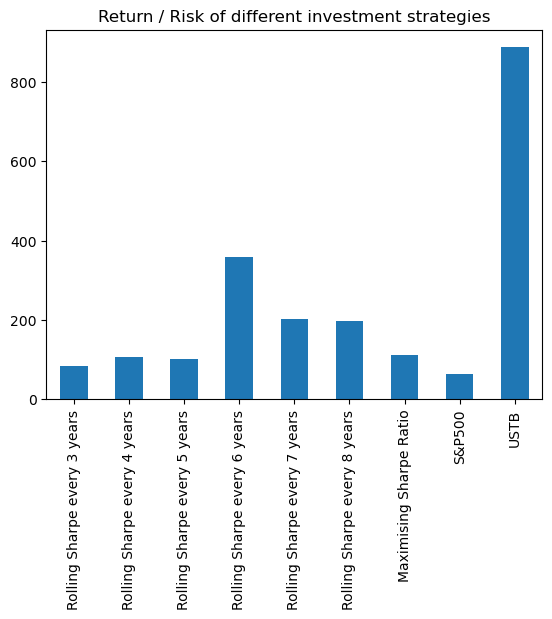

In [124]:
full_summary['Return / Risk'].plot(kind= 'bar')
plt.title("Return / Risk of different investment strategies")

Unsurprisingly USTB has the highest ratio of return / risk.
Importantly however, we found that by choosing stocks with a high sharpe ratio (reguardless of the lookback years) we outperformed the base S&P500 in terms of return/unit of risk

In [126]:
snp_volatility = full_summary.loc['S&P500', 'Volatility']

full_summary['Risk (S&P500 = 1)'] = full_summary['Volatility'] / snp_volatility
full_summary['Return / Risk (S&P500)'] = full_summary['Cumulative Return'] / full_summary['Risk (S&P500 = 1)']

print(full_summary[['Cumulative Return', 'Risk (S&P500 = 1)', 'Return / Risk (S&P500)']])


                              Cumulative Return  Risk (S&P500 = 1)  \
Rolling Sharpe every 3 years           6.640792           1.778004   
Rolling Sharpe every 4 years           7.678180           1.626272   
Rolling Sharpe every 5 years           6.346119           1.399305   
Rolling Sharpe every 6 years          21.985425           1.374012   
Rolling Sharpe every 7 years          12.437508           1.389031   
Rolling Sharpe every 8 years          14.452369           1.641763   
Maximising Sharpe Ratio                8.011800           1.605226   
S&P500                                 2.883279           1.000000   
USTB                                   1.603001           0.040597   

                              Return / Risk (S&P500)  
Rolling Sharpe every 3 years                3.734971  
Rolling Sharpe every 4 years                4.721339  
Rolling Sharpe every 5 years                4.535194  
Rolling Sharpe every 6 years               16.000901  
Rolling Sharpe every 7 y

In [128]:
full_summary

,Cumulative Return,Volatility,Return / Risk,Risk (S&P500 = 1),Return / Risk (S&P500)
Rolling Sharpe every 3 years,6.640792,0.079098,83.956465,1.778004,3.734971
Rolling Sharpe every 4 years,7.678180,0.072348,106.128510,1.626272,4.721339
Rolling Sharpe every 5 years,6.346119,0.062251,101.944270,1.399305,4.535194
Rolling Sharpe every 6 years,21.985425,0.061126,359.675910,1.374012,16.000901
Rolling Sharpe every 7 years,12.437508,0.061794,201.274290,1.389031,8.954089
Rolling Sharpe every 8 years,14.452369,0.073037,197.877074,1.641763,8.802957
Maximising Sharpe Ratio,8.011800,0.071412,112.191688,1.605226,4.991071
S&P500,2.883279,0.044487,64.811731,1.000000,2.883279
USTB,1.603001,0.001806,887.573031,0.040597,39.485459


So by normalising the risk based on the risk of the S&P500, we find that for each unit of risk our Sharpe Ratio methods outperform the S&P500. e.g 16x returns / unit of risk compared to the S&P500 at 2.88x returns / unit of risk.

## Takeaways for maximising Sharpe Ratio

### What we found

- Static Sharpe Ratio investing (buying and holding the top 10 stocks by Sharpe Ratio) produced a cumulative return of 8.01x versus the S&P500's 2.88x over the same period, whilst taking on only marginally more volatility (1.60x the S&P500's risk)

- Dynamic (Rolling) Sharpe investing produced more variable results depending on the lookback period chosen. The best performer, rebalancing every 6 years, achieved a 21.99x cumulative return and a risk-adjusted score of 16.0 — roughly 5.5x more efficient than the S&P500 on a per-unit-of-risk basis. However the worst performer (every 5 years, 4.54) only marginally beat static Sharpe investing, illustrating that no universally optimal rebalancing frequency exists, ie it depends on the dataset.

### Limitations

- The optimal rebalancing period (6 years here) was identified in hindsight. In practice this would not be known in advance, making the 16x result difficult to replicate again.
- The dynamic strategy sells stocks that leave the top 10 and buys new entrants, which may result in selling at lows and buying at highs, which is a weakness when rebalancing.
- Transaction costs and taxes from rebalancing were not modelled, which would reduce the dynamic strategy's returns in practice.

### Overall

Maximising the Sharpe Ratio is a viable and theoretically grounded investing strategy. Even in its simplest static form it meaningfully outperformed the S&P500 on both raw and risk-adjusted returns. The dynamic approach offers further upside but is very dependant on the choice of lookback period. 

With this in mind, in the future we would like to look into predicting which stocks will have a high Sharpe Ratio going forward, rather than relying on historical Sharpe Ratio and seeing what cumulative returns this may give.